# Compare Temperature and Salinity from ACCESS-CM3 to WOA

This notebook shows examples of comparing ACCESS-CM3 Temperature and Salinity structure to the WOA climatology (that is used as initial conditions for most runs). We describe the location and setup of the WOA data interpolated onto the model grids, as well as plot SST and SSS anomalies along with equatorial slices of temperature and salinity anomalies.

In [1]:
from dask.distributed import Client
client = Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 2
Total threads: 2,Total memory: 9.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40443,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40657,Total threads: 1
Dashboard: /proxy/36675/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:40171,


## WOA2023
WOA data is already a mean dataset so doesn't have time steps.

ESMValTool CMORised data - adjusted downloader and cmoriser to use 0.25deg data, temporarily in kj13.

Data documentation:
- https://www.ncei.noaa.gov/products/world-ocean-atlas
 


#### Salinity variables:
- **so** - sea water salinity with olevel
- **sos** - sea surface salinity

In [25]:
from esmvalcore.config import CFG

# CFG['rootpath']['OBS6'].append('/g/data/kj13/datasets/esmvaltool/obsdata-v2')
CFG.load_from_dirs(['/home/189/fc6164/.config/esmvaltool_new'])

In [26]:
from esmvalcore.dataset import Dataset

obs_woa = Dataset( 
            short_name='thetao', dataset='WOA', #'thetao' depth
            mip="Omon", project='OBS6', version='2023',  #v OBS6 2018, OBS 2013v2
            type='*', tier=2)

facetsn = {'short_name':'sos'}
obs_so = obs_woa.copy(**facetsn) ##use as Dataset template

# check files
list(obs_woa.files), list(obs_so.files), obs_woa.load().shape
# reference year used from esmvaltool cmor config - does not have meaning but naming convention takes time range

/home/189/fc6164/esmValTool/repos/ESMVal/ESMValCore/esmvalcore/config/_config.py:59: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/ESMValCore/pull/2747 for details). To silent this warning and ignore deprecated extra facets, set the environment variable ESMVALTOOL_USE_NEW_EXTRA_FACETS_CONFIG=1.
  warn_if_old_extra_facets_exist()
(for file /g/data/kj13/datasets/esmvaltool/obsdata-v2/Tier2/WOA/OBS6_WOA_clim_2023_Omon_thetao_200007-200007.nc)


([LocalFile('/g/data/kj13/datasets/esmvaltool/obsdata-v2/Tier2/WOA/OBS6_WOA_clim_2023_Omon_thetao_200007-200007.nc')],
 [LocalFile('/g/data/kj13/datasets/esmvaltool/obsdata-v2/Tier2/WOA/OBS6_WOA_clim_2023_Omon_sos_200007-200007.nc')],
 (1, 102, 720, 1440))

## Comparing to ACCESS-CM3 using MOPPy



In [2]:
from access_moppy import ACCESS_ESM_CMORiser
import glob


Loaded Configuration:
Creator Name: Felicity Chun
Organisation: ACCESS-NRI
Creator Email: felicity.chun@anu.edu.au
Creator URL: https://orcid.org/0009-0007-0845-0953


In [3]:
ROOT_FOLDER = "/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-29-01-2025-exp-runoff-smoothing-rmax-500-efold-1000/archive/1981/ocean/"
FILES = glob.glob(ROOT_FOLDER + "access-cm3.mom6.2d.tos.1mon.mean.*.nc")
len(FILES)

1

In [4]:
cmoriser = ACCESS_ESM_CMORiser(
    input_data=FILES,
    compound_name="Omon.tos",
    experiment_id="piControl",
    source_id="ACCESS-CM2",
    model_id="ACCESS-CM3",
    variant_label="r1i1p1f1",
    grid_label="gn",
    activity_id="CMIP",
)

/home/189/fc6164/esmValTool/repos/ACCESS-MOPPeR/src/access_moppy/driver.py:115: UserWarning: No parent_info provided. Defaulting to piControl parent experiment metadata. You should verify this is appropriate. Incorrect parent settings may lead to invalid CMIP submission.
  warnings.warn(


In [5]:
cmoriser.run()

🗓️  Monthly CMIP6 table detected (Omon.tos) - using calendar-aware validation
📂 Opening 1 files with xarray multi-file dataset...
🎯 Detected frequency from time bounds: 31 days 00:00:00
⚡ Efficiently detected frequency: 31 days 00:00:00
📅 Validated monthly data with calendar variations (detected: 31 days 00:00:00)
📅 Monthly data detected - no resampling required (calendar variations are natural)
✓ Validated compatible temporal frequency: 31 days 00:00:00
🔧 Applying intelligent dataset rechunking...
🔧 Applying dataset rechunking with rules:
  - Time coordinates: single chunk
  - Time bounds: single chunk
  - Data variables: at least 4.0MB chunks
  tos: data variable → time:10.0, yh:300, xh:360
  time_bnds: time bounds → single chunk
  time: coordinate → single chunk
  nv: data variable → nv:2
  yh: data variable → yh:300
  xh: data variable → xh:360
✅ Dataset rechunking completed
✅ Dataset rechunking completed
🔧 Normalizing missing values to NaN for consistent processing...
✅ Missing va

/home/189/fc6164/esmValTool/repos/ACCESS-MOPPeR/src/access_moppy/utilities.py:975: UserWarning: Inconsistent time intervals detected in bounds: 31 days 00:00:00 vs 28 days 00:00:00
  warnings.warn(


In [6]:
cm3_tos = cmoriser.to_iris()

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/opt/conda/analysis3-25.11/lib/gdalplugins/../libtiledb.so.2.26: undefined symbol: _ZN6google5cloud7storage5v2_286ClientC1ENS0_5v2_287OptionsE
/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/iris/fileformats/cf.py:391: IrisCfMissingVarWarning: Missing CF-netCDF boundary variab

In [7]:
cm3_tos.coord('time').guess_bounds(monthly=True)

/g/data/tm70/fc6164/pixi_cache/envs/pixi_esmval-1702579731464335260/envs/default/lib/python3.13/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


## SST and SSS biases


In [8]:
## preprocessers
from esmvalcore.preprocessor import climate_statistics
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_levels
from esmvalcore.preprocessor import extract_transect

In [15]:
model_cube = climate_statistics(cm3_tos, period='full', operator='mean')
model_cube = regrid(model_cube, target_grid='1x1', scheme="linear")

In [28]:
facetsn = {'short_name':'tos'}
obs_var = obs_woa.copy(**facetsn).load()[0] #woa has 1 time dimension
obs_cube = regrid(obs_var, target_grid='1x1', scheme="linear")
anombias = model_cube - obs_cube

In [18]:
t_coord = cm3_tos.coord('time')
start = t_coord.units.num2date(t_coord.points[0]).strftime('%Y-%m')
end = t_coord.units.num2date(t_coord.points[-1]).strftime('%Y-%m')

In [17]:
import iris.plot as iplt
import matplotlib.pyplot as plt
import numpy as np
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime

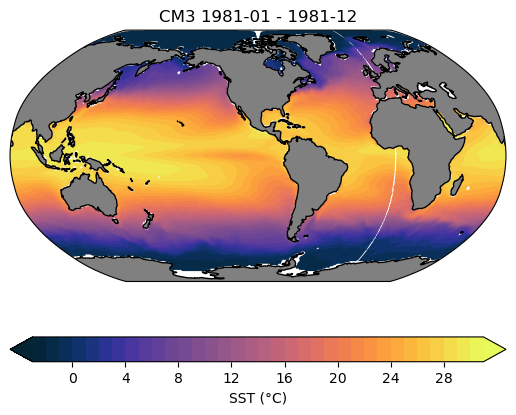

In [24]:
# plot time mean
ax = plt.subplot(projection=ccrs.Robinson(central_longitude=-100))
p0 = iplt.contourf(model_cube, axes=ax, cmap=cm.cm.thermal, extend='both', levels=np.arange(-3., 32., 1.))
ax.add_feature(cfeature.LAND, facecolor='gray')
ax.coastlines()
plt.title(f"CM3 {start} - {end}")
plt.colorbar(p0, orientation='horizontal', label='SST (°C)')
plt.show()

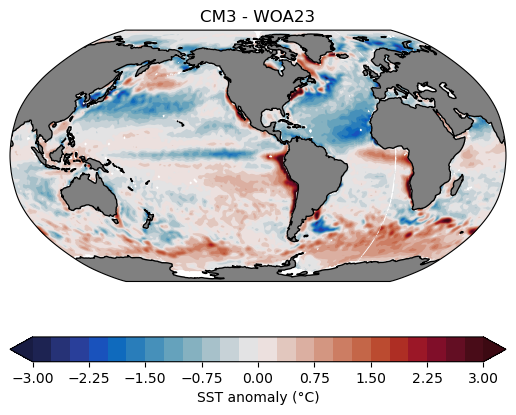

In [29]:
# plot anom
ax = plt.subplot(projection=ccrs.Robinson(central_longitude=-100))
p0 = iplt.contourf(anombias, axes=ax, cmap=cm.cm.balance, extend='both', levels=np.arange(-3, 3.25, 0.25))
ax.add_feature(cfeature.LAND, facecolor='gray')
ax.coastlines()
plt.title("CM3 - WOA23")
cb = plt.colorbar(p0, orientation='horizontal', label='SST anomaly (°C)')
plt.show()

In [9]:
## run bias for tos and sos for plot model bias, woa data 
# plot function for both

def plot_comparison(sst_cubes, ekeys, clev, labelbar, obs_levels):
    for i, ekey in enumerate(ekeys):
        ax = plt.subplot(1+len(ekeys)//2, 2, i+1, projection=ccrs.Robinson(central_longitude=-100))
        p0 = iplt.contourf(sst_cubes[ekey], axes=ax, cmap=cm.cm.balance, extend='both', levels=clev)
        ax.add_feature(cfeature.LAND, facecolor='gray')
        ax.coastlines()
        plt.title("({}) {} - WOA23".format(chr(ord('a') + i), ekey))
    
    i+=1
    
    ax1 = plt.subplot(1+len(ekeys)//2, 2, i+1, projection=ccrs.Robinson(central_longitude=-100))
    p1 = iplt.contourf(sst_cubes['WOA23'], axes=ax1, cmap=cm.cm.thermal, extend='both', levels=obs_levels)
    ax1.add_feature(cfeature.LAND, facecolor='gray')
    ax1.coastlines()
    plt.title("({}) WOA23".format(chr(ord('a') + i)))
    
    ax5 = plt.axes([0.92, 0.52, 0.01, 0.33])
    cb = plt.colorbar(p0, cax=ax5, orientation='vertical')
    cb.ax.set_ylabel(' anomaly '.join(labelbar.split(' '))) #param ^split join ' anomaly '.join(labelbar.split(' '))
    
    ax6 = plt.axes([0.92,0.13,0.01,0.33])
    cb = plt.colorbar(p1, cax=ax6, orientation='vertical')
    cb.ax.set_ylabel(labelbar) 

## To Do: update for SSS
Then we do the same for sea surface salinity biases

In [11]:
time = datetime.now()
print('start ', time)
# dict of cubes to plot
sss_cubes = {}

cube, obs = bias_woa(obs_woa, model_OM2, 'sos',"1x1")
sss_cubes['ACCESS-OM2'] = cube
sss_cubes['WOA23'] = obs
facets = {'dataset':'ACCESS-OM2-025'}
cube, obs = bias_woa(obs_woa, model_OM2.copy(**facets), 'sos', "0.25x0.25")
sss_cubes['ACCESS-OM2-025'] = cube
print(datetime.now() - time)

start  2026-02-02 11:37:21.798033
0:01:03.491363


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 64.26 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


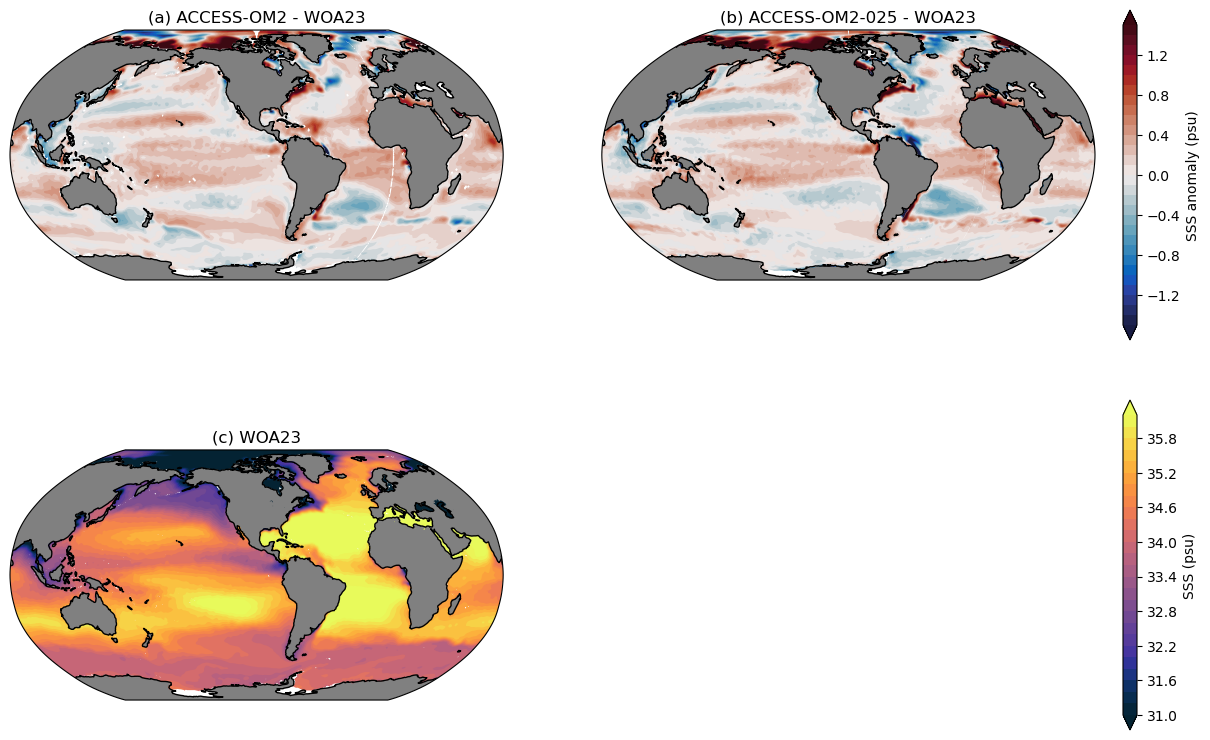

In [12]:
fig = plt.figure(figsize=(14, 10))
clev = np.arange(-1.5, 1.6, 0.1)
obs_levels=np.arange(31., 36.2, 0.2)
plot_comparison(sss_cubes, ekeys, clev, 'SSS (psu)', obs_levels)

## Equatorial Pacific Temperature and Salinity Longitude-depth biases

Our final example compares temperature and salinity biases in the tropical Pacific (note, this overlaps somewhat with the `Equatorial_thermal_and_zonal_velocity_structure.ipynb` COSIMA documented example).

Follow similar process defining function to use for both variables

In [13]:
# longitude-depth analysis - extract transect

def lon_depth_bias(obs, model, shortname, grid):
    facetsn = {'short_name':shortname} #thetao, so
    
    model_cube = model.copy(**facetsn).load()
    model_cube = regrid(model_cube, target_grid=grid, scheme="linear")
    model_cube = extract_transect(model_cube, latitude=0.)
    model_cube = climate_statistics(model_cube, period='full', operator='mean')
    depths = list(model_cube.coord('depth').points)
    u, mean = model_cube.units, model_cube.data.mean()
    print(u, mean)
    if mean > 200: # error with model units listed as C when values are K
        model_cube = mod_units(model_cube)
        
    # model da
    obs_cube = obs.copy(**facetsn).load()[0] #woa has 1 time dimension
    obs_cube = regrid(obs_cube, target_grid=grid, scheme="linear")
    obs_cube = extract_transect(obs_cube, latitude=0.)
    obs_cube = extract_levels(obs_cube, depths, scheme='linear')
    
    # anombias = model_cube - obs_cube # do outside function
    return model_cube, obs_cube

def mod_units(cbfix):
    cbfix.units = "K"
    return convert_units(cbfix, 'degC')

def format_longitude(x, pos):
    if x > 180:
        return f'{int(360 - x)}°W'
    elif x == 180:
        return f'{int(x)}°'
    else:
        return f'{int(x)}°E'

In [14]:
time = datetime.now()
print(time)
# dict of cubes to plot
sstdepth_cubes = {}

modcube, obs = lon_depth_bias(obs_woa, model_OM2, 'thetao',"1x1")
sstdepth_cubes['ACCESS-OM2'] = (modcube, obs) # - obs in plot

facets = {'dataset':'ACCESS-OM2-025'}
mod2cube, obs = lon_depth_bias(obs_woa, model_OM2.copy(**facets), 'thetao', "0.25x0.25")
sstdepth_cubes['ACCESS-OM2-025'] = (mod2cube, obs) #- obs
print(datetime.now() - time)

2026-02-02 11:39:21.307940


(for file /g/data/kj13/datasets/esmvaltool/obsdata-v2/Tier2/WOA/OBS6_WOA_clim_2023_Omon_thetao_200007-200007.nc)


degC 286.4066524520256


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 65.02 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


degC 286.59870720512066


(for file /g/data/kj13/datasets/esmvaltool/obsdata-v2/Tier2/WOA/OBS6_WOA_clim_2023_Omon_thetao_200007-200007.nc)


0:13:57.707769


Then plotting equatorial plots of temperature biases

In [15]:
# Define contour levels
clev, isos = np.arange(-3.,3.25,0.25), np.arange(0, 32, 2)

# Define a function to plot Equatorial Slices
def plot_eqtemp(ekeys, sst_cubes, clev, isos, cblabel, linelabel):

    # Loop through models
    for i, ekey in enumerate(ekeys):
        mod, obs = sst_cubes[ekey]
        ax1 = plt.subplot(1, 2, i+1) #int(np.ceil(len(ekeys)/2))
        bias = mod - obs
        # Plot bias as color #y axis decreaseing ..*-1
        pn = iplt.contourf(bias, axes=ax1, cmap='bwr', levels=clev)#, yincrease=False)
        
        # Plot WOA13 isotherms (and 20C bold)
        CS = iplt.contour(obs, axes=ax1, levels=isos, colors='k')
        ax1.clabel(CS, inline=False, fmt='%d', fontsize=15)
        iplt.contour(obs, axes=ax1, levels=[20.], colors='k', linewidths=3.)
        
        cube_add = bias + obs #
        iplt.contour(cube_add, axes=ax1, levels=[20.], colors='k', linewidths=3., linestyles='--')
        
        ax1.invert_yaxis()
        # Add annotations
        plt.title("({}) {}".format(chr(ord('a') + i), ekey))
        ax1.set_ylim([300., 0.])
        ax1.set_xlim([140, 280]) #[-220., -80.])
        ax1.set_ylabel('Depth (m)')
        ax1.set_xlabel('Longitude')
        plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))
        if i == 0:
            ax1.text(150., 275., f'WOA23 {linelabel}', fontsize=15)

    ax5 = plt.axes([0.92, 0.2, 0.01, 0.5])
    cb = plt.colorbar(pn, cax=ax5, orientation='vertical')
    cb.ax.set_ylabel(cblabel)

Plot temperature comparison

1
CPU times: user 901 ms, sys: 145 ms, total: 1.05 s
Wall time: 5.36 s


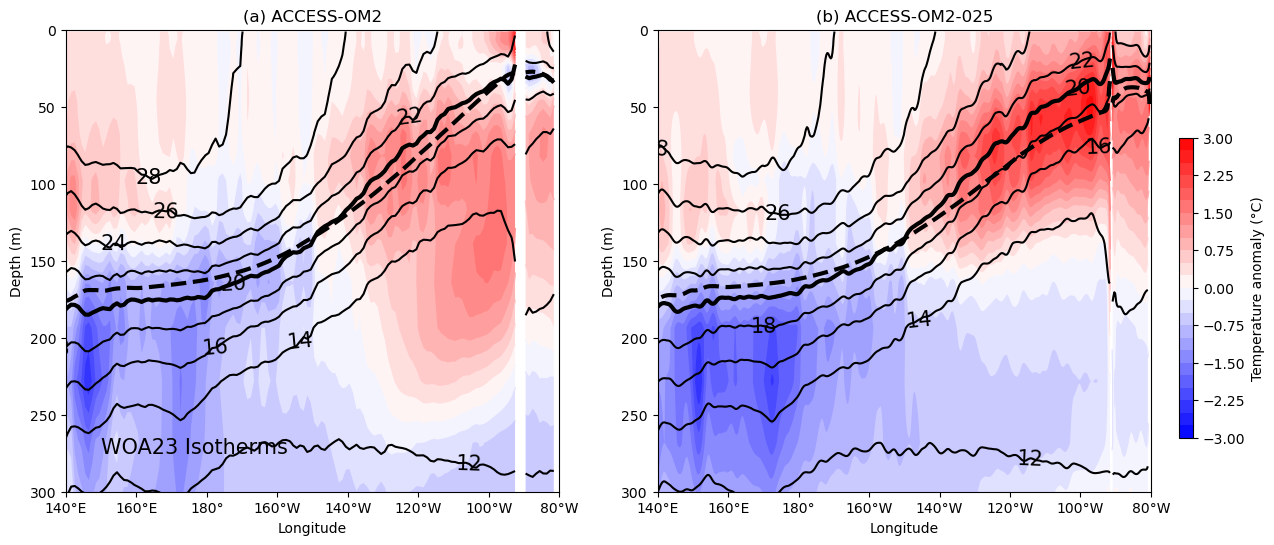

In [16]:
print(int(np.ceil(len(ekeys)/2)))
fig = plt.figure(figsize=(14, 6))
# Define contour levels
clev = np.arange(-3.,3.25,0.25)
isotherms = np.arange(0, 32, 2)

ekeys = ['ACCESS-OM2','ACCESS-OM2-025']
plot_eqtemp(ekeys,sstdepth_cubes, clev, isotherms,'Temperature anomaly (°C)', 'Isotherms') #, 'SSS (psu)'

And finally, repeat the same for salinity.

In [17]:
time = datetime.now()
print(time)
# dict of cubes to plot
sodepth_cubes = {}

modcube, obs = lon_depth_bias(obs_woa, model_OM2, 'so',"1x1")
sodepth_cubes['ACCESS-OM2'] = (modcube, obs)

facets = {'dataset':'ACCESS-OM2-025'}
mod2cube, obs = lon_depth_bias(obs_woa, model_OM2.copy(**facets), 'so', "0.25x0.25")
sodepth_cubes['ACCESS-OM2-025'] = (mod2cube, obs)
print(datetime.now() - time)

(for file /g/data/kj13/datasets/esmvaltool/obsdata-v2/Tier2/WOA/OBS6_WOA_clim_2023_Omon_so_200007-200007.nc)


0.001 34.99070095948827


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 65.02 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


0.001 34.9509569629848


(for file /g/data/kj13/datasets/esmvaltool/obsdata-v2/Tier2/WOA/OBS6_WOA_clim_2023_Omon_so_200007-200007.nc)


CPU times: user 3min 21s, sys: 1min 30s, total: 4min 51s
Wall time: 14min 9s


CPU times: user 846 ms, sys: 269 ms, total: 1.11 s
Wall time: 5.19 s


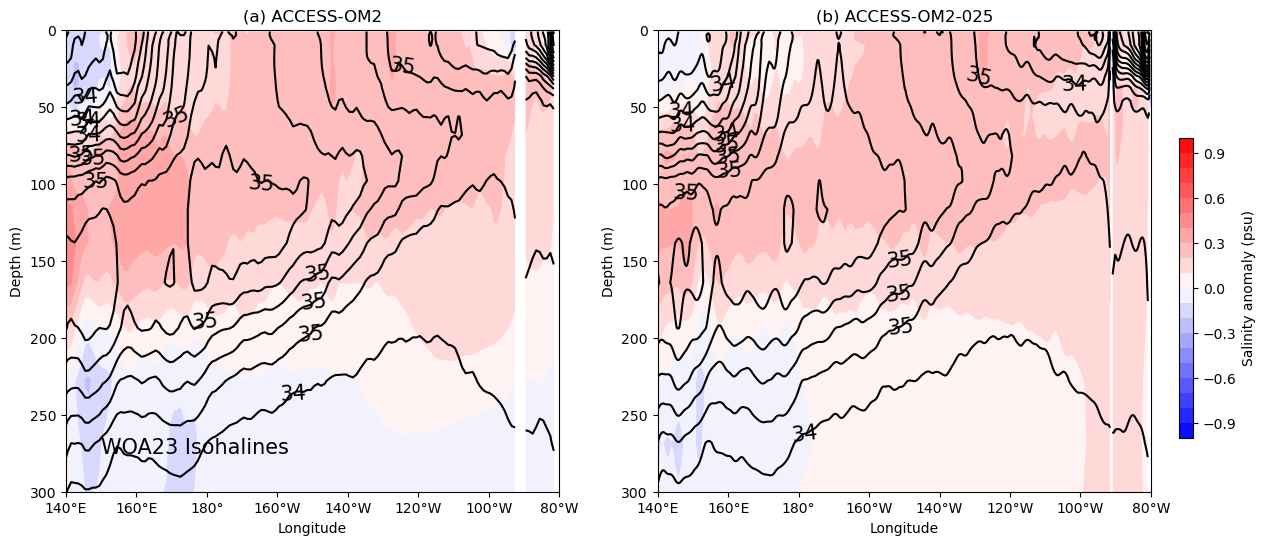

In [18]:

fig = plt.figure(figsize=(14, 6))
# Define contour levels
clev = np.arange(-1., 1.1, 0.1)
isohalines = np.arange(30., 36.1, 0.1)

ekeys = ['ACCESS-OM2','ACCESS-OM2-025']
plot_eqtemp(ekeys, sodepth_cubes, clev, isohalines, 'Salinity anomaly (psu)', 'Isohalines') #contour line label settings